In [1]:
from micrograd.scaler.engine import Value
import micrograd.scaler.nn as nn  
from micrograd.scaler.nn import binary_cross_entropy, evaluate
import random

In [ ]:
# Data Generation
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

X, y = make_classification(
    n_samples=1000,
    n_features=10,
    n_informative=6,
    n_classes=2,
    random_state=42
)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((800, 10), (200, 10), (800,), (200,))

In [3]:
model = nn.Sequential(
    nn.Linear(10, 32),
    nn.ReLU(),
    nn.Linear(32, 1),
    nn.Sigmoid()
)

model

Sequential(
    Linear: (10, 32),
    ReLU(),
    Linear: (32, 1),
    Sigmoid()
)

Parameters: 385

In [4]:
# Training Loop
BATCH_SIZE = 32
EPOCHS = 20
lr = 0.1

train_losses = []
train_accs = []
test_losses = []
test_accs = []

for epoch in range(EPOCHS):
    data = list(zip(X_train, y_train))
    random.shuffle(data)
    X_train, y_train = zip(*data)
    X_train = list(X_train)
    y_train = list(y_train)

    for i in range(0, len(X), BATCH_SIZE):
        X_batch = X[i: i + BATCH_SIZE]
        y_batch = y[i : i + BATCH_SIZE]
        losses = []
        for x_i, y_i in zip(X_batch, y_batch):
            y_pred = model(x_i)
            loss = binary_cross_entropy(y_pred,y_i)
            losses.append(loss)
        loss = sum(losses) * (1 / len(losses))
        model.zero_grad()
        loss.backward()
        for p in model.parameters():
            p.data -= lr * p.grad
    
    train_loss, train_acc = evaluate(model, X_train, y_train)
    test_loss, test_acc = evaluate(model, X_test, y_test)

    train_losses.append(train_loss)
    train_accs.append(train_acc)
    test_losses.append(test_loss)
    test_accs.append(test_acc)

    print(
        f"Epoch: {epoch+1} | "
        f"train_loss: {train_loss:.4f} | "
        f"train_acc: {train_acc:.3f} | "
        f"test_loss: {test_loss:.4f} | "
        f"test_acc: {test_acc:.3f} | "
    )

Epoch: 1 | train_loss: 0.4328 | train_acc: 0.810 | test_loss: 0.3825 | test_acc: 0.840 | 
Epoch: 2 | train_loss: 0.3690 | train_acc: 0.836 | test_loss: 0.3182 | test_acc: 0.860 | 
Epoch: 3 | train_loss: 0.3337 | train_acc: 0.849 | test_loss: 0.2894 | test_acc: 0.870 | 
Epoch: 4 | train_loss: 0.3093 | train_acc: 0.856 | test_loss: 0.2723 | test_acc: 0.885 | 
Epoch: 5 | train_loss: 0.2901 | train_acc: 0.860 | test_loss: 0.2598 | test_acc: 0.885 | 
Epoch: 6 | train_loss: 0.2746 | train_acc: 0.880 | test_loss: 0.2508 | test_acc: 0.890 | 
Epoch: 7 | train_loss: 0.2621 | train_acc: 0.886 | test_loss: 0.2444 | test_acc: 0.900 | 
Epoch: 8 | train_loss: 0.2514 | train_acc: 0.895 | test_loss: 0.2399 | test_acc: 0.915 | 
Epoch: 9 | train_loss: 0.2424 | train_acc: 0.904 | test_loss: 0.2364 | test_acc: 0.915 | 
Epoch: 10 | train_loss: 0.2353 | train_acc: 0.909 | test_loss: 0.2335 | test_acc: 0.925 | 
Epoch: 11 | train_loss: 0.2291 | train_acc: 0.912 | test_loss: 0.2307 | test_acc: 0.930 | 
Epoch: 1

In [11]:
train_losses

[0.43279309176065156,
 0.369039515456057,
 0.3336594307638726,
 0.3093178975824333,
 0.2900601205698034,
 0.27461792397821194,
 0.26207482427175044,
 0.2513929711920715,
 0.24240815702611154,
 0.23525755846967475,
 0.22908560493124047,
 0.22315068344532288,
 0.21824364746552485,
 0.21372505945388842,
 0.21013676495539077,
 0.20639933879942365,
 0.20202445614648445,
 0.19894765252102245,
 0.19619609586409895,
 0.19386632886561173]

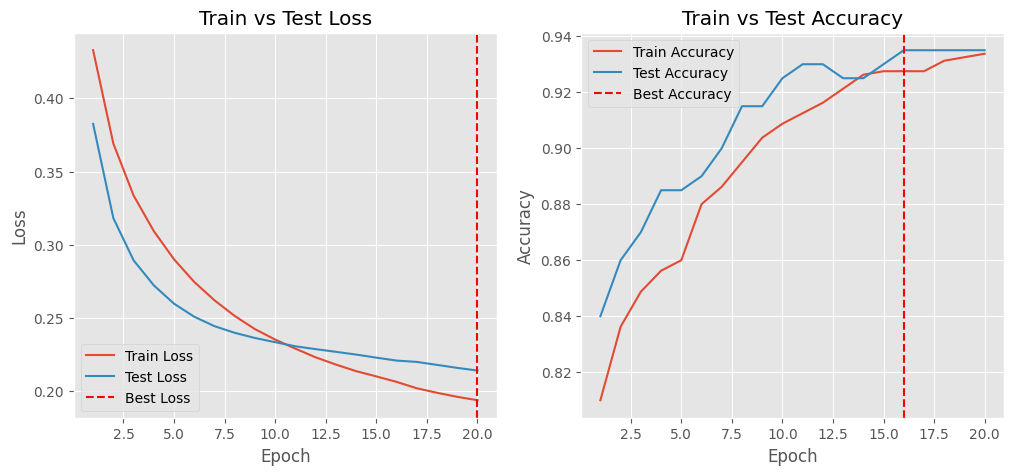

In [50]:
import matplotlib.pyplot as plt
plt.style.use("ggplot")


epochs = range(1, len(train_losses) + 1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs, train_losses, label="Train Loss")
plt.plot(epochs, test_losses, label="Test Loss")
best_loss = test_losses.index(min(test_losses)) + 1
plt.axvline(best_loss, linestyle="--", color="red", label="Best Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Train vs Test Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, train_accs, label="Train Accuracy")
plt.plot(epochs, test_accs, label="Test Accuracy")
best_epoch = test_accs.index(max(test_accs)) + 1
plt.axvline(best_epoch, linestyle="--", color="red", label="Best Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Train vs Test Accuracy")
plt.legend()
